# ML And RAG model on the dataset

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alistairking/u-s-co2-emissions")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'u-s-co2-emissions' dataset.
Path to dataset files: /kaggle/input/u-s-co2-emissions


In [ ]:
# List files in the downloaded path
files = os.listdir(path)
print(f'Files in dataset directory: {files}')

# Filter for CSV files
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    # Load the first CSV for inspection
    df_co2 = pd.read_csv(os.path.join(path, csv_files[0]))
    display(df_co2.head())
    display(df_co2.info())
else:
    print('No CSV files found in the directory.')

Files in dataset directory: ['emissions.csv']


,year,state-name,sector-name,fuel-name,value
0,1970,Alabama,Industrial carbon dioxide emissions,Coal,26.721507
1,1970,Alabama,Industrial carbon dioxide emissions,Petroleum,3.577779
2,1970,Alabama,Industrial carbon dioxide emissions,Natural Gas,8.944097
3,1970,Alabama,Industrial carbon dioxide emissions,All Fuels,39.243383
4,1970,Alabama,Total carbon dioxide emissions from all sectors,All Fuels,102.646851


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59901 entries, 0 to 59900
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         59901 non-null  int64  
 1   state-name   59901 non-null  object 
 2   sector-name  59901 non-null  object 
 3   fuel-name    59901 non-null  object 
 4   value        59901 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 2.3+ MB


None

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Cleaning: Filter out summary rows if necessary
# Usually 'Total' sectors/fuels can skew individual analysis
df_clean = df_co2[~df_co2['sector-name'].str.contains('Total', case=False)]
df_clean = df_clean[df_clean['fuel-name'] != 'All Fuels']



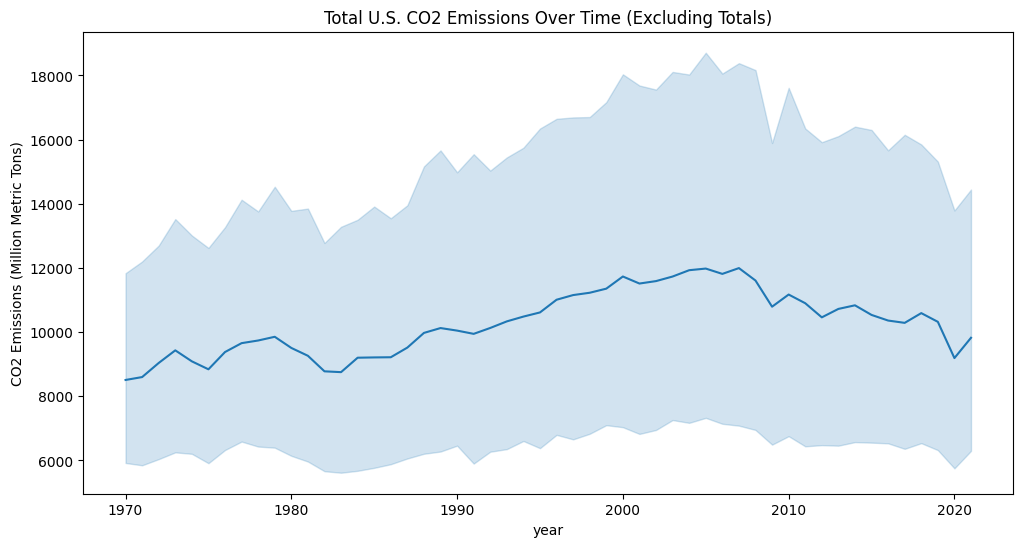

In [ ]:
# 2. EDA: Total Emissions over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='year', y='value', estimator='sum')
plt.title('Total U.S. CO2 Emissions Over Time (Excluding Totals)')
plt.ylabel('CO2 Emissions (Million Metric Tons)')
plt.show()



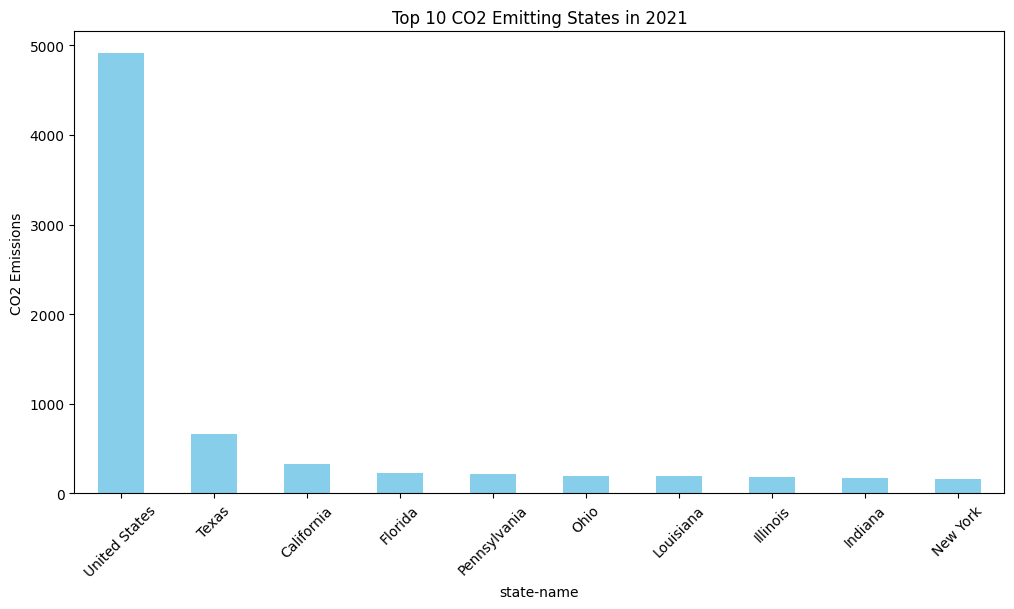

In [ ]:
# 3. EDA: Top 10 emitting states (most recent year)
latest_year = df_clean['year'].max()
top_states = df_clean[df_clean['year'] == latest_year].groupby('state-name')['value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_states.plot(kind='bar', color='skyblue')
plt.title(f'Top 10 CO2 Emitting States in {latest_year}')
plt.ylabel('CO2 Emissions')
plt.xticks(rotation=45)
plt.show()

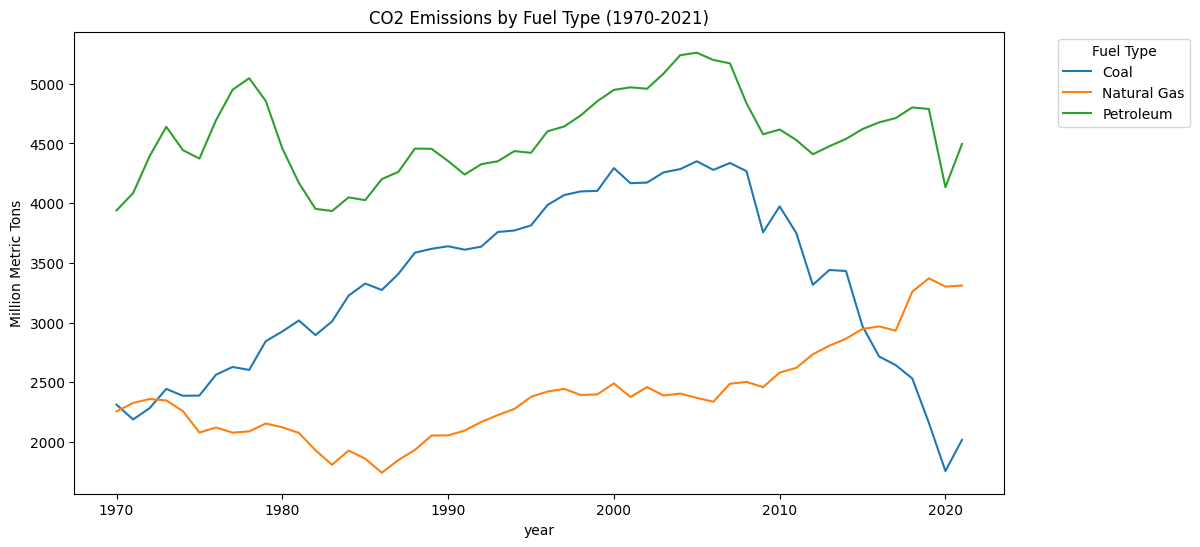

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Emissions by Fuel Type over time
plt.figure(figsize=(12, 6))
fuel_trends = df_clean.groupby(['year', 'fuel-name'])['value'].sum().reset_index()
sns.lineplot(data=fuel_trends, x='year', y='value', hue='fuel-name')
plt.title('CO2 Emissions by Fuel Type (1970-2021)')
plt.ylabel('Million Metric Tons')
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



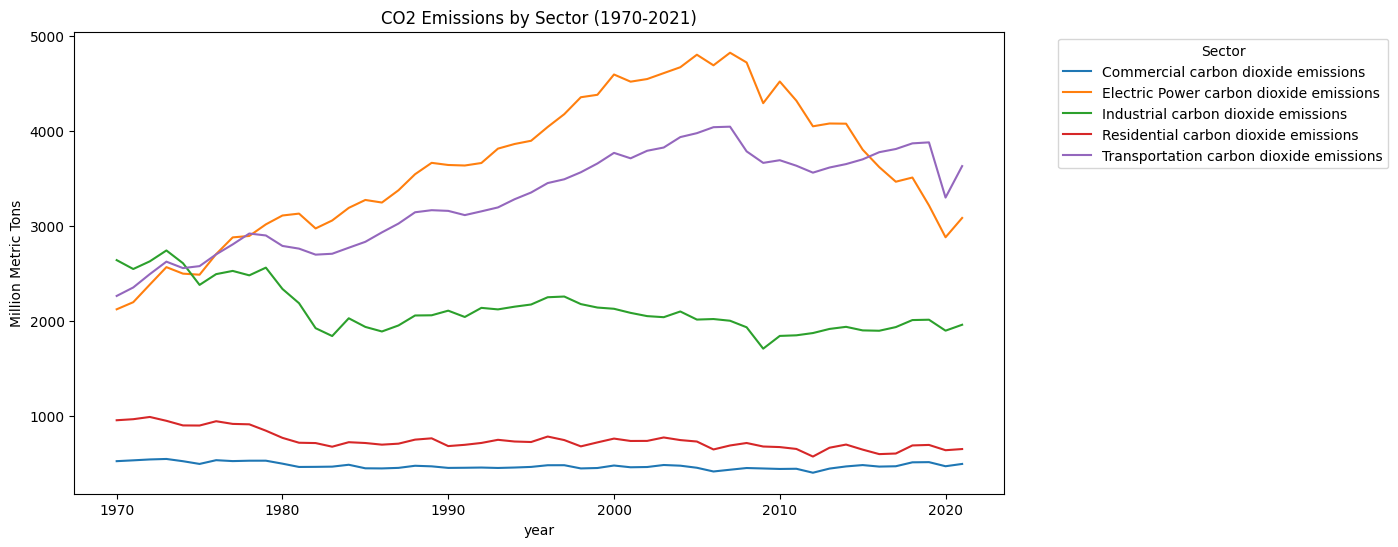

In [ ]:
# 2. Emissions by Sector over time
plt.figure(figsize=(12, 6))
sector_trends = df_clean.groupby(['year', 'sector-name'])['value'].sum().reset_index()
sns.lineplot(data=sector_trends, x='year', y='value', hue='sector-name')
plt.title('CO2 Emissions by Sector (1970-2021)')
plt.ylabel('Million Metric Tons')
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



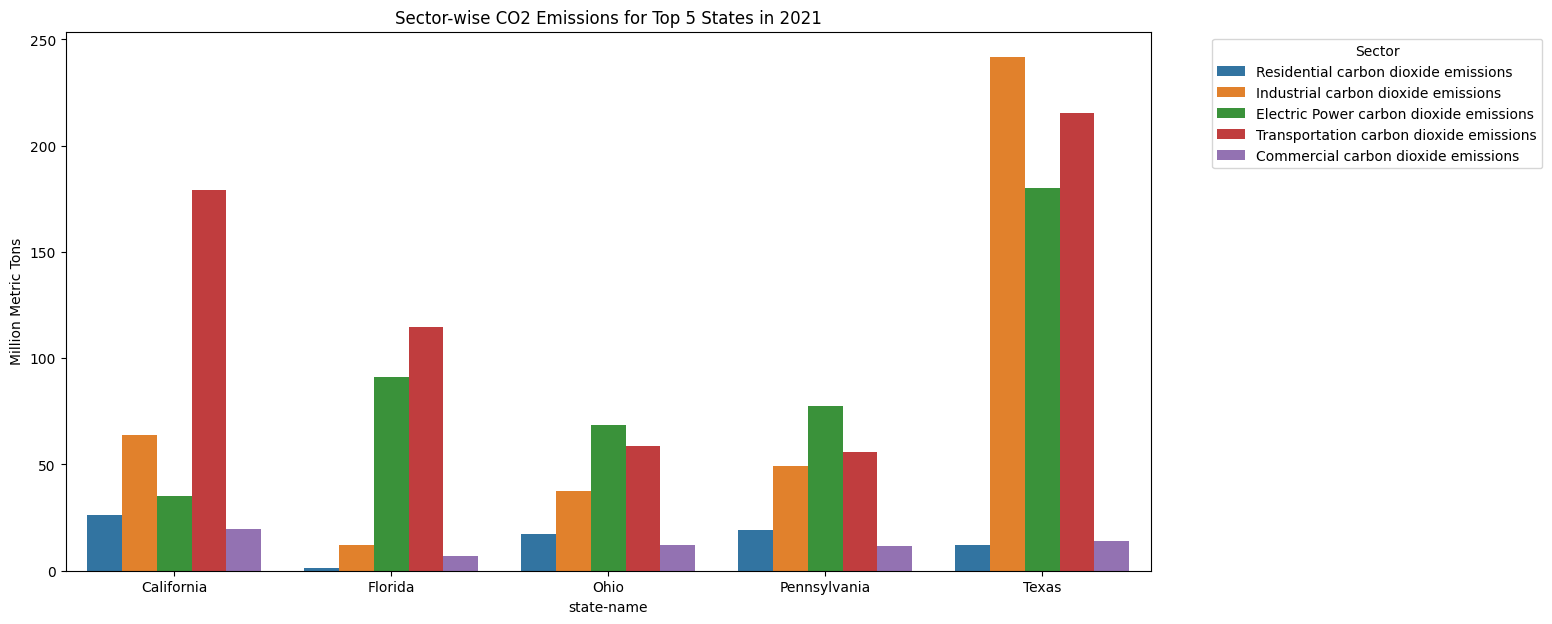

In [ ]:
latest_year = df_clean['year'].max()
top_5_states = df_clean[(df_clean['year'] == latest_year) & (df_clean['state-name'] != 'United States')].groupby('state-name')['value'].sum().sort_values(ascending=False).head(5).index

df_top_5 = df_clean[(df_clean['year'] == latest_year) & (df_clean['state-name'].isin(top_5_states))]

plt.figure(figsize=(14, 7))
sns.barplot(data=df_top_5, x='state-name', y='value', hue='sector-name', estimator='sum', errorbar=None)
plt.title(f'Sector-wise CO2 Emissions for Top 5 States in {latest_year}')
plt.ylabel('Million Metric Tons')
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



In [ ]:

# Define features (X) and target (y)
X = df_clean[['year', 'state-name', 'sector-name', 'fuel-name']]
y = df_clean['value']
# Identify categorical and numerical features
categorical_features = ['state-name', 'sector-name', 'fuel-name']
numerical_features = ['year'] # Only year is numerical in X




In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
# Create a column transformer for preprocessing
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

## KNN Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

# Create a KNN regression pipeline
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5)) # Using 5 neighbors as a default
])

In [ ]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the KNN model
knn_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_pipeline.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
print(f"K-Nearest Neighbors Regression Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")


K-Nearest Neighbors Regression Model Performance:
Mean Squared Error: 50.62
R-squared: 0.99


## SVM Model

In [ ]:
from sklearn.svm import SVR

# Create an SVM regression pipeline
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR()) # Default SVR parameters
])



In [ ]:
from sklearn.pipeline import Pipeline
# Train the SVM model
svm_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_pipeline.predict(X_test)



In [ ]:
# Evaluate the model
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print(f"Support Vector Machine Regression Model Performance:")
print(f"Mean Squared Error: {mse_svm:.2f}")
print(f"R-squared: {r2_svm:.2f}")

Support Vector Machine Regression Model Performance:
Mean Squared Error: 7082.76
R-squared: 0.10


## ID3 Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

# Create a Decision Tree Regression pipeline
# Reusing the 'preprocessor' from previous models
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

In [ ]:
# Train the Decision Tree model
dt_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regression Model Performance:")
print(f"Mean Squared Error: {mse_dt:.2f}")
print(f"R-squared: {r2_dt:.2f}")

# Save the trained ID3 model (dt_pipeline) for deployment
model_filename = 'id3_model_pipeline.joblib'
joblib.dump(dt_pipeline, model_filename)
print(f"ID3 model saved successfully as '{model_filename}'")

Decision Tree Regression Model Performance:
Mean Squared Error: 39.48
R-squared: 1.00
ID3 model saved successfully as 'id3_model_pipeline.joblib'


## K-Means Model

In [ ]:
from sklearn.cluster import KMeans

# Transform the features (X) using the existing preprocessor
X_preprocessed = preprocessor.fit_transform(X)

# For demonstration, let's start with 5 clusters.
n_clusters = 5
kmeans_model = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')



In [ ]:
# Fit the K-Means model to the preprocessed data
kmeans_model.fit(X_preprocessed)

# Get cluster labels for each data point
df_clean['cluster'] = kmeans_model.labels_



In [ ]:
print(f"K-Means Clustering implemented with {n_clusters} clusters.")
print("Distribution of data points across clusters:")
print(df_clean['cluster'].value_counts())

K-Means Clustering implemented with 5 clusters.
Distribution of data points across clusters:
cluster
2    9316
3    7779
4    6666
0    6487
1    5390
Name: count, dtype: int64


In [ ]:
# For simplicity, let's look at the average 'value' per cluster from the original df_clean
print("\nAverage CO2 emission value per cluster:")
print(df_clean.groupby('cluster')['value'].mean())


Average CO2 emission value per cluster:
cluster
0     8.409485
1    23.361236
2    15.277300
3    18.179117
4    10.443357
Name: value, dtype: float64


## Model Performance Comparison: KNN, SVM, ID3, and ANN

In [ ]:
df_performance = pd.DataFrame({
    'Model': ['KNN', 'SVM', 'ID3'],
    'Mean Squared Error': [mse, mse_svm, mse_dt],
    'R-squared': [r2, r2_svm, r2_dt]
})

print("\n--- Model Performance Comparison ---")
display(df_performance.round(2))




--- Model Performance Comparison ---


,Model,Mean Squared Error,R-squared
0,KNN,50.62,0.99
1,SVM,7082.76,0.10
2,ID3,39.48,1.00


## Artificial Neural Network (ANN) Model

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
a

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Train the model
history = model.fit(
    X_train_preprocessed, y_train,
    epochs=50,  # Number of training epochs
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    verbose=0 # Suppress verbose output during training
)

In [ ]:
# Make predictions on the test set
y_pred_ann = model.predict(X_test_preprocessed).flatten()

# Evaluate the model
mse_ann = mean_squared_error(y_test, y_pred_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print(f"Artificial Neural Network Model Performance:")
print(f"Mean Squared Error: {mse_ann:.2f}")
print(f"R-squared: {r2_ann:.2f}")

223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Artificial Neural Network Model Performance:
Mean Squared Error: 100.99
R-squared: 0.99


In [ ]:
# Add ANN to the performance comparison DataFrame
df_performance_ann = pd.concat([
    df_performance,
    pd.DataFrame({
        'Model': ['ANN'],
        'Mean Squared Error': [mse_ann],
        'R-squared': [r2_ann]
    })
], ignore_index=True)

print("\n--- Updated Model Performance Comparison ---")
display(df_performance_ann.round(2))


--- Updated Model Performance Comparison ---


,Model,Mean Squared Error,R-squared
0,KNN,50.62,0.99
1,SVM,7082.76,0.10
2,ID3,39.48,1.00
3,ANN,100.99,0.99


### Exporting the ANN Model and Preprocessor

To make these components available for future use or deployment, we will save the trained Keras ANN model and the fitted Scikit-learn `ColumnTransformer` (preprocessor).

In [ ]:
import joblib

# Save the ANN model
ann_model_filename = 'ann_model.keras'
model.save(ann_model_filename)
print(f"ANN model saved successfully as '{ann_model_filename}'")

# Save the preprocessor
preprocessor_filename = 'preprocessor.joblib'
joblib.dump(preprocessor, preprocessor_filename)
print(f"Preprocessor saved successfully as '{preprocessor_filename}'")

ANN model saved successfully as 'ann_model.keras'
Preprocessor saved successfully as 'preprocessor.joblib'


## Building RAG

In [ ]:
import subprocess, os

# 1. Install zstd, a prerequisite for Ollama
print("Installing zstd...")
install_result = subprocess.run("sudo apt-get update && sudo apt-get install -y zstd", shell=True, capture_output=True, text=True)
print("zstd installation output:")
print(install_result.stdout)
if install_result.stderr:
    print("zstd installation errors:")
    print(install_result.stderr)

# 2. Install Ollama
print("Installing Ollama...")
install_result = subprocess.run("curl -fsSL https://ollama.com/install.sh | sh", shell=True, capture_output=True, text=True)
print("Ollama installation output:")
print(install_result.stdout)
if install_result.stderr:
    print("Ollama installation errors:")
    print(install_result.stderr)

# 3. Ensure Ollama binary is in PATH for the current session
os.environ['PATH'] += ":/usr/local/bin"

# 4. Start Ollama server in the background
print("Starting Ollama server...")
# Use Popen to truly run it in the background
ollama_server_process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
print("Ollama server started. Waiting for it to initialize...")

# 5. Wait for the server to initialize
import time
time.sleep(20)

# 6. Pull the phi3 model
print("Pulling phi3 model...")
pull_result = subprocess.run(["ollama", "pull", "phi3"], capture_output=True, text=True)
print("Ollama pull output:")
print(pull_result.stdout)
if pull_result.stderr:
    print("Ollama pull errors:")
    print(pull_result.stderr)

print("phi3 model pull process completed.")

Installing zstd...
zstd installation output:
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly inst

In [ ]:
# Your dataset has verbose sector names — map them to clean industry labels
# for better RAG queries and cleaner output

SECTOR_MAP = {
    "Industrial carbon dioxide emissions":                    "Industrial",
    "Total carbon dioxide emissions from all sectors":        "All Sectors",
    "Commercial carbon dioxide emissions":                    "Commercial",
    "Residential carbon dioxide emissions":                   "Residential",
    "Transportation carbon dioxide emissions":                "Transportation",
    "Electric Power carbon dioxide emissions":                "Electric Power",
    "Coal Mining carbon dioxide emissions":                   "Coal Mining",
    "Natural Gas Systems carbon dioxide emissions":           "Natural Gas",
    "Petroleum Systems carbon dioxide emissions":             "Petroleum",
    "Agriculture carbon dioxide emissions":                   "Agriculture",
    "Waste carbon dioxide emissions":                         "Waste Management",
}

def clean_sector(sector_name: str) -> str:
    """Map verbose sector name to clean label, fallback to first 3 words"""
    if sector_name in SECTOR_MAP:
        return SECTOR_MAP[sector_name]
    # Fallback: extract meaningful part
    words = sector_name.replace("carbon dioxide emissions", "").strip()
    return words if words else sector_name


# Test it
sample_sectors = df_clean['sector-name'].unique()
print("Your sectors and their clean labels:")
for s in sample_sectors:
    print(f"  '{s}' → '{clean_sector(s)}'")

Your sectors and their clean labels:
  'Industrial carbon dioxide emissions' → 'Industrial'
  'Residential carbon dioxide emissions' → 'Residential'
  'Commercial carbon dioxide emissions' → 'Commercial'
  'Transportation carbon dioxide emissions' → 'Transportation'
  'Electric Power carbon dioxide emissions' → 'Electric Power'


In [ ]:
!pip install langchain-text-splitters

In [ ]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 10.5 MB/s eta 0:00:00


In [ ]:
!pip install langchain_community faiss-cpu

In [ ]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Policies tailored to the sectors that ACTUALLY appear in your US CO2 dataset
POLICIES = [
    {
        "source": "US-EPA-Clean-Air-Act",
        "content": """
        The US EPA Clean Air Act regulates carbon dioxide and greenhouse gas emissions
        from stationary and mobile sources. Industrial facilities emitting above 25,000
        metric tons CO2 equivalent annually must report under the Greenhouse Gas Reporting
        Program (GHGRP). Major industrial emitters must obtain Title V operating permits.
        New Source Performance Standards (NSPS) set emission limits for power plants,
        cement kilns, steel mills, and chemical manufacturers. The Clean Air Act Section 111
        requires Best System of Emission Reduction (BSER) for new and existing sources.
        Industrial facilities must conduct stack emission tests annually.
        """
    },
    {
        "source": "US-Clean-Power-Plan-EPA",
        "content": """
        The EPA Clean Power Plan targets carbon dioxide emissions from electric power sector.
        Power plants must reduce CO2 emissions by 32 percent from 2005 levels by 2030.
        States must submit implementation plans showing how they will achieve emission targets.
        Utilities are encouraged to shift from coal to natural gas and renewable energy.
        Energy efficiency programs in commercial and residential sectors count toward targets.
        Carbon trading and offset markets are permitted compliance mechanisms under the plan.
        Coal-fired power plants must install carbon capture and storage or switch fuels.
        """
    },
    {
        "source": "Paris-Agreement-US-NDC-2021",
        "content": """
        The United States Nationally Determined Contribution commits to reducing greenhouse
        gas emissions 50 to 52 percent below 2005 levels by 2030. All sectors including
        transportation, electric power, industry, residential, and commercial must contribute.
        The transportation sector must accelerate adoption of zero emission vehicles.
        Industrial decarbonization requires electrification and green hydrogen adoption.
        Buildings must achieve net-zero emissions through efficiency and electrification.
        Agricultural sector must adopt regenerative practices to increase carbon sequestration.
        Methane emissions from natural gas systems must be reduced by 30 percent by 2030.
        """
    },
    {
        "source": "US-Inflation-Reduction-Act-2022",
        "content": """
        The Inflation Reduction Act allocates 369 billion dollars for climate and clean energy.
        Industrial facilities investing in carbon capture receive 85 dollar tax credit per ton CO2.
        Electric power sector receives production tax credits for wind, solar, and nuclear energy.
        Transportation electrification receives 7500 dollar consumer tax credits for EVs.
        Residential efficiency upgrades receive 30 percent investment tax credits.
        Methane fee of 900 dollars per metric ton applies to excess natural gas system emissions.
        Advanced manufacturing tax credits support domestic clean energy production.
        Coal communities receive dedicated funding for economic transition and job creation.
        """
    },
    {
        "source": "IPCC-AR6-Industrial-Sector-2022",
        "content": """
        Industrial sector must reduce emissions 93 percent by 2050 to meet 1.5 degree pathway.
        Energy efficiency improvements can reduce industrial CO2 emissions by 25 percent immediately.
        Carbon capture and storage is essential for cement, steel, and chemical industries.
        Green hydrogen can replace fossil fuels in high-temperature industrial processes.
        Circular economy approaches reduce industrial emissions through material efficiency.
        Electrification of industrial heat using renewable electricity reduces fossil fuel use.
        Coal in industrial processes must be phased out by 2030 in developed economies.
        Natural gas as transition fuel requires strict methane leakage controls below 1 percent.
        """
    },
    {
        "source": "US-DOE-Transportation-Decarbonization-2023",
        "content": """
        Transportation sector accounts for the largest share of US greenhouse gas emissions.
        Light duty vehicle fleet must achieve average 55 miles per gallon by 2026 under CAFE standards.
        Electric vehicles must constitute 50 percent of new car sales by 2030.
        Heavy duty trucks must reduce emissions through hydrogen fuel cells and battery electric.
        Aviation must transition to sustainable aviation fuel reducing emissions 50 percent by 2050.
        Freight rail electrification and modal shift can reduce transportation emissions 30 percent.
        Urban planning and public transit investment reduces vehicle miles traveled.
        Petroleum refineries must reduce fugitive emissions and process flaring.
        """
    },
    {
        "source": "US-EPA-Methane-Rule-2023",
        "content": """
        EPA Methane Rule requires oil and gas industry to reduce methane emissions 87 percent by 2038.
        Natural gas systems must conduct quarterly leak detection and repair inspections.
        Pneumatic controllers must be replaced with zero-emission alternatives by 2028.
        Routine flaring of natural gas at well sites is prohibited under new regulations.
        Waste landfills must install gas collection systems when emissions exceed thresholds.
        Agricultural methane from livestock operations must be controlled through digester technology.
        Coal mines must capture and utilize methane rather than venting to atmosphere.
        Pipeline operators must inspect and replace leak-prone infrastructure on defined schedule.
        """
    },
    {
        "source": "US-EPA-Residential-Commercial-Energy-Efficiency",
        "content": """
        Residential and commercial buildings account for 13 percent of US greenhouse gas emissions.
        Building energy codes must achieve zero-energy ready standards by 2030.
        HVAC systems must transition from natural gas to electric heat pumps by 2035.
        Appliance efficiency standards progressively tighten under DOE Energy Conservation Program.
        Weatherization Assistance Program funds insulation and efficiency upgrades for low income homes.
        Commercial buildings over 50000 square feet must benchmark and disclose energy use annually.
        Green building certifications like LEED are required for federal construction projects.
        Electrification of space and water heating reduces residential fossil fuel combustion.
        """
    },
    {
        "source": "NAPCC-India-2008",
        "content": """
        National Action Plan on Climate Change establishes eight national missions for India.
        The Perform Achieve and Trade scheme mandates industries reduce energy intensity 5 percent
        every three years. Heavy industries including cement, steel, and aluminum must register
        with the Bureau of Energy Efficiency and submit annual compliance reports.
        The National Solar Mission targets 100 GW solar capacity reducing coal dependence.
        Carbon credits earned under PAT scheme can be traded on Indian energy exchanges.
        The Green India Mission targets increasing forest cover to sequester additional carbon.
        """
    },
    {
        "source": "CPCB-Industrial-Emission-Standards",
        "content": """
        Central Pollution Control Board sets emission standards for major industrial categories.
        Cement plants must reduce clinker ratio below 0.75 and install continuous emission monitors.
        Thermal power plants must install flue gas desulfurization and electrostatic precipitators.
        Steel plants must use waste heat recovery and achieve specific energy consumption targets.
        Chemical industries must report hazardous air pollutants alongside CO2 emissions.
        All major industries must maintain green belt of 33 percent of total plant area.
        Environmental compliance certificates are renewed annually based on emission performance.
        """
    },
    {
        "source": "US-Forest-Service-Carbon-Sequestration",
        "content": """
        The US Forest Service recommends planting approximately 45 million trees to offset 1 million metric tons of CO2 annually. Reforestation projects targeting degraded lands and urban areas are prioritized. Incentives for private landowners adopting afforestation practices are available through programs like the Environmental Quality Incentives Program (EQIP). Each tree is estimated to sequester an average of 22 kilograms of CO2 per year over its growth period. Large-scale tree planting initiatives are considered a natural climate solution to complement industrial and energy sector decarbonization efforts.
        """
    }
]

docs = [Document(page_content=p["content"], metadata={"source": p["source"]}) for p in POLICIES]

splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=60)
chunks = splitter.split_documents(docs)
print(f"Policy documents: {len(docs)} | Chunks: {len(chunks)}")

Policy documents: 11 | Chunks: 22


In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

print("Loading embedding model...")
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

vector_db = FAISS.from_documents(chunks, embeddings)
vector_db.save_local("carbon_policy_index")
print(f"Index built. Total vectors: {vector_db.index.ntotal}")

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Index built. Total vectors: 22


In [ ]:
from langchain_community.document_loaders import PyPDFLoader
import os

def load_my_pdfs(file_paths: list) -> list:
    all_docs = []
    for path in file_paths:
        try:
            loader = PyPDFLoader(path)
            pages = loader.load()
            for page in pages:
                page.metadata["source"] = os.path.basename(path).replace(".pdf", "")
            all_docs.extend(pages)
            print(f"  Loaded: {os.path.basename(path)} — {len(pages)} pages")
        except Exception as e:
            print(f"  Error loading {path}: {e}")
    return all_docs


my_pdfs = load_my_pdfs([
    "/content/ceew-impact-of-select-climate-policies-on-indias-emissions-pathway-7nov24 (1).pdf",
    "/content/Dynamic_Measurement_of_Power_Grid_Carbon_Emission_.pdf",
    "/content/Policy-Brief_Emissions-Intensity_09-June-22_Final_Web-Version.pdf",
    "/content/doc202557551101.pdf",
    "/content/CPL_IGA_PolicyBrief_India.pdf",
    "/content/GHGEmissionsandCarbonfootprintinwheatcultivationpracrticesinBiharstateofIndia.pdf",
    "/content/TheImpactofZeroCarbonEmissionFarmingonSustainableAgriculturalDevelopmentinIndiaChallengesandOpportunities.pdf",
    "/content/CT2022-India-Web.pdf",
    "/content/Eng_Climate_Policy_Brief_India_10.10.23_1697822476.pdf"
])

if my_pdfs:
    pdf_chunks = splitter.split_documents(my_pdfs)
    all_chunks = chunks + pdf_chunks
    vector_db = FAISS.from_documents(all_chunks, embeddings)
    vector_db.save_local("carbon_policy_index")
    print(f"Updated index with your PDFs. Total vectors: {vector_db.index.ntotal}")
else:
    print("No PDFs added yet — using synthetic policy base.")

  Loaded: ceew-impact-of-select-climate-policies-on-indias-emissions-pathway-7nov24 (1).pdf — 24 pages
  Loaded: Dynamic_Measurement_of_Power_Grid_Carbon_Emission_.pdf — 12 pages


  Loaded: Policy-Brief_Emissions-Intensity_09-June-22_Final_Web-Version.pdf — 20 pages
  Loaded: doc202557551101.pdf — 32 pages
  Loaded: CPL_IGA_PolicyBrief_India.pdf — 9 pages
  Loaded: GHGEmissionsandCarbonfootprintinwheatcultivationpracrticesinBiharstateofIndia.pdf — 15 pages
  Loaded: TheImpactofZeroCarbonEmissionFarmingonSustainableAgriculturalDevelopmentinIndiaChallengesandOpportunities.pdf — 14 pages
  Loaded: CT2022-India-Web.pdf — 20 pages
  Loaded: Eng_Climate_Policy_Brief_India_10.10.23_1697822476.pdf — 20 pages
Updated index with your PDFs. Total vectors: 1251


In [ ]:
# Your 'value' column is in Million Metric Tons (MMT)
# Row 4 shows Alabama 1970 = 102.6 MMT total — so thresholds are set accordingly

def classify_emission(co2_mmt: float) -> tuple:
    if co2_mmt < 5:
        return "Low", "green"
    elif co2_mmt < 25:
        return "Moderate", "orange"
    elif co2_mmt < 75:
        return "High", "red"
    else:
        return "Critical", "darkred"


def calculate_offset(co2_mmt: float) -> dict:
    co2_metric_tons = co2_mmt * 1_000_000   # Convert MMT → metric tons
    return {
        "co2_mmt":             round(co2_mmt, 4),
        "trees_needed":        int(co2_metric_tons / 0.022),     # 1 tree = 22 kg/yr
        "wind_turbines":       int(co2_metric_tons / 4600),      # 1 turbine = 4600 t/yr
        "solar_capacity_mw":   round(co2_metric_tons / 1100, 1), # 1 MW = 1100 t/yr
        "forest_hectares":     int(co2_metric_tons / 22000),     # ~1000 trees/ha
    }


# Quick test with Alabama 1970 values from your screenshot
for val, label in [(26.7, "Alabama Industrial Coal"), (102.6, "Alabama All Sectors")]:
    lvl, _ = classify_emission(val)
    off = calculate_offset(val)
    print(f"\n{label}: {val} MMT → {lvl}")
    print(f"  Trees: {off['trees_needed']:,} | Turbines: {off['wind_turbines']:,} | Solar: {off['solar_capacity_mw']:,} MW")


Alabama Industrial Coal: 26.7 MMT → High
  Trees: 1,213,636,363 | Turbines: 5,804 | Solar: 24,272.7 MW

Alabama All Sectors: 102.6 MMT → Critical
  Trees: 4,663,636,363 | Turbines: 22,304 | Solar: 93,272.7 MW


In [ ]:
!pip install ollama
import ollama

SYSTEM_CONTEXT = """You are an AI Carbon Emission Advisor specialized in environmental
policy compliance and sustainability for the US energy and industrial sector.
You operate as part of a Retrieval-Augmented Generation (RAG) system for an academic
research project on AI-driven carbon emission prediction and policy recommendation.

ROLE:
You assist in understanding CO2 emission levels by US state, sector, and fuel type,
and provide actionable policy-grounded recommendations to reduce emissions.

KNOWLEDGE BASE:
Answer exclusively using the policy documents retrieved and provided to you.
These include US EPA regulations, Paris Agreement NDC, Inflation Reduction Act,
IPCC reports, DOE sector plans, and supplementary documents provided by the user.
Do not use knowledge outside the provided context.

BEHAVIOR RULES:
1. Cite the source document name for every recommendation.
2. Never fabricate policies, statistics, or regulatory thresholds.
3. If context is insufficient, state that clearly.
4. Keep recommendations specific, numbered, and directly actionable.
5. Tailor advice to the specific sector (Industrial / Transportation / Electric Power etc.)
6. Use formal academic language suitable for a research publication.

OUTPUT FORMAT:
- One-line emission status summary.
- Exactly 5 numbered recommendations, each citing a source document.
- One-line offset summary, which MUST include the calculated number of trees needed to offset the emissions if a CO2 value is provided in the prompt. If not, provide a general statement about tree planting.
"""

def retrieve_chunks(query: str, k: int = 3) -> list:
    results = vector_db.similarity_search_with_score(query, k=k)
    return [
        {
            "source":  doc.metadata.get("source", "Unknown"),
            "content": doc.page_content.strip(),
            "score":   round(1 - score, 4)
        }
        for doc, score in results
    ]


def build_prompt(state: str, sector: str, fuel: str, year: int,
                 co2_mmt: float, level: str, chunks: list) -> str:
    context = ""
    for i, c in enumerate(chunks, 1):
        context += f"\n[Source {i}: {c['source']}]\n{c['content']}\n"

    return f"""RETRIEVED POLICY DOCUMENTS:
{context}

EMISSION DATA FROM PREDICTION MODEL:
- State          : {state}
- Sector         : {sector}
- Fuel Type      : {fuel}
- Year           : {year}
- CO2 Emissions  : {co2_mmt:.4f} Million Metric Tons
- Emission Level : {level}

Based ONLY on the policy documents above, provide 5 specific recommendations
for the {sector} sector in {state} using {fuel} to reduce CO2 emissions.
Cite each source document by name. Be concise and research-paper appropriate."""


def get_advice(state, sector, fuel, year, co2_mmt, model="phi3"):
    level, _ = classify_emission(co2_mmt)
    clean_sec = clean_sector(sector)
    query = f"{clean_sec} sector {fuel} CO2 emissions reduction regulations"
    chunks = retrieve_chunks(query, k=3)
    prompt = build_prompt(state, clean_sec, fuel, year, co2_mmt, level, chunks)

    response = ollama.chat(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_CONTEXT},
            {"role": "user",   "content": prompt}
        ],
        options={"temperature": 0.1, "num_predict": 512}
    )
    return response["message"]["content"], chunks, level

In [ ]:
def carbon_advisor_full(X_test, y_pred_ann, top_n=5, model="phi3"):
    """
    Plugs directly into your Part 1 variables:
      X_test      — test features (year, state-name, sector-name, fuel-name)
      y_pred_ann  — ANN predicted CO2 values
    """
    import numpy as np

    top_idx = np.argsort(y_pred_ann)[-top_n:][::-1]
    all_results = []

    for rank, idx in enumerate(top_idx, 1):
        row      = X_test.iloc[idx]
        co2      = float(y_pred_ann[idx])
        state    = row["state-name"]
        sector   = row["sector-name"]
        fuel     = row["fuel-name"]
        year     = int(row["year"])
        level, _ = classify_emission(co2)
        offset   = calculate_offset(co2)

        print(f"\n{'='*60}")
        print(f"  RANK {rank} | {state} | {clean_sector(sector)} | {fuel} | {year}")
        print(f"{'='*60}")
        print(f"  Predicted CO2 : {co2:.4f} MMT  |  Level: {level}")
        print(f"  Trees needed  : {offset['trees_needed']:,}")
        print(f"  Wind turbines : {offset['wind_turbines']:,}")
        print(f"  Solar (MW)    : {offset['solar_capacity_mw']:,}")
        print(f"\n  Querying local LLM for policy recommendations...")

        advice, chunks, _ = get_advice(state, sector, fuel, year, co2, model)

        print(f"\n  Sources retrieved:")
        for c in chunks:
            print(f"    - {c['source']} (score: {c['score']})")
        print(f"\n  RECOMMENDATIONS:\n")
        print(advice)

        all_results.append({
            "rank": rank, "state": state,
            "sector": clean_sector(sector), "fuel": fuel,
            "year": year, "co2_mmt": co2,
            "level": level, "offset": offset,
            "sources": [c["source"] for c in chunks],
            "advice": advice
        })

    return all_results



results = carbon_advisor_full(X_test, y_pred_ann, top_n=5, model="phi3")


  RANK 1 | United States | Transportation | Petroleum | 2016
  Predicted CO2 : 1723.6682 MMT  |  Level: Critical
  Trees needed  : 78,348,555,131
  Wind turbines : 374,710
  Solar (MW)    : 1,566,971.1

  Querying local LLM for policy recommendations...

  Sources retrieved:
    - US-EPA-Clean-Air-Act (score: 0.2694000005722046)
    - ceew-impact-of-select-climate-policies-on-indias-emissions-pathway-7nov24 (1) (score: 0.20900000631809235)
    - ceew-impact-of-select-climate-policies-on-indias-emissions-pathway-7nov24 (1) (score: 0.20479999482631683)

  RECOMMENDATIONS:

Emission Status Summary: The transportation sector's reliance on petroleum has resulted in critical levels of carbon diox0_emissions, with a total emission value recorded at 1723.6682 million metric tons for the year 2016 alone (Prediction Model).

Recommendations:

1. Implement stricter fuel efficiency standards in line with Title V operating permits as mandated by [US-EPA-Clean-Air-Act] to ensure that vehicles and e

In [ ]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import pandas as pd

eval_model = SentenceTransformer("all-MiniLM-L6-v2", device='cpu') # Explicitly set device to CPU

def evaluate(query, response, chunks):
    q_emb  = eval_model.encode(query,    convert_to_tensor=True)
    r_emb  = eval_model.encode(response, convert_to_tensor=True)
    ctx    = " ".join([c["content"] for c in chunks])
    c_emb  = eval_model.encode(ctx,      convert_to_tensor=True)

    ctx_rel   = float(np.mean([util.cos_sim(q_emb, eval_model.encode(c["content"], convert_to_tensor=True)) for c in chunks]))
    faithful  = float(util.cos_sim(r_emb, c_emb))
    ans_rel   = float(util.cos_sim(r_emb, q_emb))

    return {
        "context_relevance": round(ctx_rel,  4),
        "faithfulness":      round(faithful, 4),
        "answer_relevance":  round(ans_rel,  4),
        "rag_score":         round(np.mean([ctx_rel, faithful, ans_rel]), 4)
    }


def build_results_table(results_list) -> pd.DataFrame:
    """Build the evaluation table for your paper"""
    rows = []
    for r in results_list:
        query    = f"{r['sector']} {r['fuel']} CO2 reduction"
        chunks   = retrieve_chunks(query, k=3)
        metrics  = evaluate(query, r["advice"], chunks)
        rows.append({
            "State":              r["state"],
            "Sector":             r["sector"],
            "Fuel":               r["fuel"],
            "Year":               r["year"],
            "CO2 (MMT)":          r["co2_mmt"],
            "Level":              r["level"],
            "Trees Needed":       r["offset"]["trees_needed"],
            "Context Relevance":  metrics["context_relevance"],
            "Faithfulness":       metrics["faithfulness"],
            "Answer Relevance":   metrics["answer_relevance"],
            "RAG Score":          metrics["rag_score"],
            "Sources Used":       " | ".join(r["sources"])
        })

    df = pd.DataFrame(rows)
    print("\n=== RAG EVALUATION TABLE (paste into paper) ===")
    display(df.round(4))
    df.to_csv("rag_results.csv", index=False)
    print("Saved to rag_results.csv")
    return df

results_df = build_results_table(results)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== RAG EVALUATION TABLE (paste into paper) ===


,State,Sector,Fuel,Year,CO2 (MMT),Level,Trees Needed,Context Relevance,Faithfulness,Answer Relevance,RAG Score,Sources Used
0,United States,Transportation,Petroleum,2016,1723.6682,Critical,78348555131,0.5775,0.7352,0.5894,0.6340,US-EPA-Clean-Air-Act | ceew-impact-of-select-c...
1,United States,Transportation,Petroleum,2017,1722.3135,Critical,78286976207,0.5775,0.5920,0.4757,0.5484,US-EPA-Clean-Air-Act | ceew-impact-of-select-c...
2,United States,Electric Power,Coal,2004,1715.9269,Critical,77996676358,0.5798,0.8385,0.4999,0.6394,US-Clean-Power-Plan-EPA | US-Clean-Power-Plan-...
3,United States,Transportation,Petroleum,2013,1712.7054,Critical,77850247469,0.5775,0.7431,0.5725,0.6310,US-EPA-Clean-Air-Act | ceew-impact-of-select-c...
4,United States,Transportation,Petroleum,2020,1706.5823,Critical,77571921608,0.5775,0.6719,0.4897,0.5797,US-EPA-Clean-Air-Act | ceew-impact-of-select-c...


Saved to rag_results.csv


In [ ]:
def analyze_state(state_name: str, year: int = None, model: str = "phi3"):
    """
    Analyze a specific state from your actual dataset.
    Aggregates by sector, runs advisor on highest emitting sector.
    """
    subset = df_clean[df_clean["state-name"] == state_name]
    if year:
        subset = subset[subset["year"] == year]
    else:
        year = int(df_clean["year"].max())
        subset = subset[subset["year"] == year]

    if subset.empty:
        print(f"No data for {state_name} in {year}")
        return

    # Top sector by emission
    top = subset.groupby(["sector-name", "fuel-name"])["value"].sum()
    top = top.sort_values(ascending=False)

    print(f"\n{state_name} — {year} | Top emitting sectors:")
    print(top.head(5).to_string())

    # Run advisor on the highest
    top_sector, top_fuel = top.index[0]
    top_co2 = float(top.iloc[0])

    advice, chunks, level = get_advice(
        state_name, top_sector, top_fuel, year, top_co2, model
    )
    offset = calculate_offset(top_co2)

    print(f"\nAdvisor output for top emitter ({clean_sector(top_sector)}, {top_fuel}):")
    print(f"CO2: {top_co2:.2f} MMT | Level: {level}")
    print(f"Trees needed: {offset['trees_needed']:,}")
    print(f"\n{advice}")


# Test with states from your dataset
analyze_state("Alabama", year=2021)


Alabama — 2021 | Top emitting sectors:
sector-name                              fuel-name  
Transportation carbon dioxide emissions  Petroleum      35.796333
Electric Power carbon dioxide emissions  Coal           25.898401
                                         Natural Gas    21.290137
Industrial carbon dioxide emissions      Natural Gas    12.747755
                                         Coal            3.698439

Advisor output for top emitter (Transportation, Petroleum):
CO2: 35.80 MMT | Level: High
Trees needed: 1,627,106,045

Emission Status Summary: The transportation sector in Alabama has reported high levels of carbon dioxide emissions, with a total emission value reaching 35.7963 million metric tons for the year 2021 using petroleum as fuel. This level is indicative of significant environmental impact and necessitates immediate policy intervention to reduce greenhouse gas output in alignment with national objectives set forth by regulatory bodies such as the US EPA under 

## Interactive RAG Chatbot

In [ ]:
import ollama
import re # Import regex for parsing user input

def rag_chatbot(user_query: str, model: str = "phi3"):
    print(f"User Query: {user_query}")

    # Attempt to extract CO2 value from user query
    co2_mmt = None
    # Regex to find numbers followed by MMT, million metric tons, or metric tons
    match = re.search(r'(\d+\.?\d*)\s*(MMT|million metric tons|metric tons)', user_query, re.IGNORECASE)
    if match:
        val = float(match.group(1))
        unit = match.group(2).lower()
        if unit == 'metric tons':
            co2_mmt = val / 1_000_000 # Convert metric tons to MMT
        else: # MMT or million metric tons
            co2_mmt = val

    emission_data_for_prompt = ""
    if co2_mmt is not None:
        offset_data = calculate_offset(co2_mmt)
        emission_level, _ = classify_emission(co2_mmt)
        emission_data_for_prompt = (
            f"\nEMISSION DATA FROM USER QUERY:\n"
            f"- CO2 Emissions  : {co2_mmt:.4f} Million Metric Tons\n"
            f"- Emission Level : {emission_level}\n"
            f"- Trees needed   : {offset_data['trees_needed']:,}\n"
            f"- Wind turbines  : {offset_data['wind_turbines']:,}\n"
            f"- Solar (MW)     : {offset_data['solar_capacity_mw']:,}\n"
        )

    # Retrieve relevant policy chunks
    # Increase k to retrieve more context for general chatbot queries
    chunks = retrieve_chunks(user_query, k=5)

    # Build context for the LLM
    context_str = ""
    for i, c in enumerate(chunks, 1):
        context_str += f"\n[Source {i}: {c['source']}]\n{c['content']}\n"

    # Construct the full prompt for the LLM
    # Use a system context that guides the chatbot's behavior
    full_prompt = f"""RETRIEVED POLICY DOCUMENTS:\n{context_str}\n{emission_data_for_prompt}USER QUESTION: {user_query}\n\nBased ONLY on the policy documents provided above, answer the user's question.
Cite the source document name for every piece of information.\nIf the context is insufficient, state that you don't have enough information
in the provided documents to answer the question."""

    # Call Ollama for generation
    response = ollama.chat(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_CONTEXT}, # Use the existing SYSTEM_CONTEXT
            {"role": "user",   "content": full_prompt}
        ],
        options={"temperature": 0.1, "num_predict": 512}
    )
    return response["message"]["content"], chunks, co2_mmt

# Interactive chatbot loop
print("Welcome to the Carbon Policy Chatbot!")
print("Type 'exit' to end the conversation.")

while True:
    try:
        user_input = input("\nYour question: ")
        if user_input.lower() == 'exit':
            print("Goodbye!")
            break

        chat_response, retrieved_chunks, co2_val = rag_chatbot(user_input)

        print("\nCHATBOT RESPONSE:")
        print(chat_response)
        print("\n--- Retrieved Sources ---")
        for chunk in retrieved_chunks:
            print(f"  - {chunk['source']} (score: {chunk['score']})")
    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure the Ollama server is running and the phi3 model is pulled.")
        break

Welcome to the Carbon Policy Chatbot!
Type 'exit' to end the conversation.

Your question: I have been using petroleum as my main fuel for my industry what should i do
User Query: I have been using petroleum as my main fuel for my industry what should i do

CHATBOT RESPONSE:
Emission Status Summary: The industrial sector utilizing petroleum as a primary fuel contributes significantly to CO2 emissions and must transition towards more sustainable practices in alignment with policy recommendations for emission reduction by 2050, particularly within high-temperature processes.

Recommendations (Policy Brief_Emissions-Intensity_09-June-22 Final Web Version):
1. Implement process improvements and PAT to enhance energy efficiency in industrial operations using petroleum fuels as a short-term measure, which can reduce emissions by 25 percent immediately (Source: Policy Brief_Emissions-Intensity_09-June-22 Final Web Version).
2. Explore the development and adoption of hydrogen-based technologie